# Data Exploration: `transfers_model_2018_2025.parquet`

**Purpose:** Understand the structure, quality, and characteristics of our master dataset before modeling.

**Dataset:** Player-season records enriched with transfer metadata, Wyscout performance metrics, z-scores, and team-level statistics. Each row represents a player's season — either a "from" (pre-transfer) or "to" (post-transfer) context, or a non-transfer season.

**Column groups (539 total):**
| Group | Prefix/Columns | Count | Description |
|---|---|---|---|
| Player identity | `wy_player_id`, `wyscout_*`, `short_name`, `birth_date`, `player_season_age` | ~13 | Player demographics & IDs |
| Transfer metadata | `transfer_type`, `tm_*`, `competition_start_date`, `first/last_played_date` | ~10 | Transfer type, fees, dates, contract |
| Pre-transfer performance | `from_*` (excl. team_stats, z_score, comp) | ~50 | Wyscout qualities + per-90 metrics at origin |
| Pre-transfer z-scores | `from_z_score_*` | ~75 | Position-adjusted z-scores at origin |
| Pre-transfer competition | `from_comp_*` | ~8 | Origin competition metadata |
| Pre-transfer team stats | `from_team_stats_*` | ~75 | Origin team aggregate stats |
| Post-transfer performance | `to_*` (excl. team_stats, z_score, comp) | ~50 | Same metrics at destination |
| Post-transfer z-scores | `to_z_score_*` | ~75 | Position-adjusted z-scores at destination |
| Post-transfer competition | `to_comp_*` | ~8 | Destination competition metadata |
| Post-transfer team stats | `to_team_stats_*` | ~75 | Destination team aggregate stats |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid", font_scale=0.9)

DATA_PATH = "../../../thesis_data/processed_data/master_dataset/transfers_model_2018_2025.parquet"
df = pd.read_parquet(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Shape: 262,340 rows x 539 columns
Memory usage: 1.00 GB


## 1. Column Classification

Programmatically group columns by their prefix/type to confirm the structure described above.

In [2]:
# Classify columns into semantic groups
def classify_columns(columns):
    groups = {
        "player_identity": [],
        "transfer_metadata": [],
        "from_performance": [],
        "from_z_scores": [],
        "from_competition": [],
        "from_team_stats": [],
        "to_performance": [],
        "to_z_scores": [],
        "to_competition": [],
        "to_team_stats": [],
    }

    identity_cols = {
        "wy_player_id", "wyscout_birth_country", "wyscout_first_name", "wyscout_foot",
        "wyscout_height", "wyscout_image_url", "wyscout_last_name", "wyscout_passport",
        "wyscout_role", "wyscout_weight", "short_name", "birth_date", "player_season_age",
    }
    transfer_cols = {
        "transfer_type", "competition_start_date", "first_played_date", "last_played_date",
        "tm_player_id", "tm_transfer_date", "tm_transfer_value", "tm_transfer_fee",
        "tm_remaining_contract_days", "tm_contract_until_date",
    }

    for col in columns:
        if col in identity_cols:
            groups["player_identity"].append(col)
        elif col in transfer_cols:
            groups["transfer_metadata"].append(col)
        elif col.startswith("from_z_score_"):
            groups["from_z_scores"].append(col)
        elif col.startswith("from_team_stats_"):
            groups["from_team_stats"].append(col)
        elif col.startswith("from_comp_"):
            groups["from_competition"].append(col)
        elif col.startswith("from_"):
            groups["from_performance"].append(col)
        elif col.startswith("to_z_score_"):
            groups["to_z_scores"].append(col)
        elif col.startswith("to_team_stats_"):
            groups["to_team_stats"].append(col)
        elif col.startswith("to_comp_"):
            groups["to_competition"].append(col)
        elif col.startswith("to_"):
            groups["to_performance"].append(col)
    return groups

col_groups = classify_columns(df.columns)

print("Column group sizes:")
for name, cols in col_groups.items():
    print(f"  {name:25s} → {len(cols):3d} columns")
print(f"  {'TOTAL':25s} → {sum(len(v) for v in col_groups.values()):3d} / {len(df.columns)}")

Column group sizes:
  player_identity           →  13 columns
  transfer_metadata         →  10 columns
  from_performance          → 101 columns
  from_z_scores             →  75 columns
  from_competition          →   8 columns
  from_team_stats           →  74 columns
  to_performance            → 101 columns
  to_z_scores               →  75 columns
  to_competition            →   8 columns
  to_team_stats             →  74 columns
  TOTAL                     → 539 / 539


## 2. Data Types & Missing Values Overview

In [3]:
# Dtype distribution
print("=== Data type counts ===")
print(df.dtypes.value_counts().to_string())
print()

# Missing values summary per group
print("=== Missing values by column group ===")
for group_name, cols in col_groups.items():
    if not cols:
        continue
    sub = df[cols]
    total_cells = sub.shape[0] * sub.shape[1]
    missing_cells = sub.isnull().sum().sum()
    cols_with_any_missing = (sub.isnull().sum() > 0).sum()
    pct = 100 * missing_cells / total_cells if total_cells > 0 else 0
    print(f"  {group_name:25s} | {cols_with_any_missing:3d}/{len(cols):3d} cols have nulls | {pct:5.1f}% cells missing")

=== Data type counts ===
float32           342
float64           157
object             21
int32               7
datetime64[ns]      6
datetime64[us]      2
Float64             2
int16               2

=== Missing values by column group ===
  player_identity           |   9/ 13 cols have nulls |  53.7% cells missing
  transfer_metadata         |   6/ 10 cols have nulls |  25.3% cells missing
  from_performance          |  42/101 cols have nulls |   7.8% cells missing
  from_z_scores             |  75/ 75 cols have nulls |   8.9% cells missing
  from_competition          |   8/  8 cols have nulls |  27.6% cells missing
  from_team_stats           |  74/ 74 cols have nulls |   9.4% cells missing
  to_performance            |  42/101 cols have nulls |   7.8% cells missing
  to_z_scores               |  75/ 75 cols have nulls |   8.9% cells missing
  to_competition            |   8/  8 cols have nulls |  26.3% cells missing
  to_team_stats             |  74/ 74 cols have nulls |   7.2% cel

In [4]:
# Top 30 columns by missing percentage
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct_nonzero = missing_pct[missing_pct > 0]

print(f"Columns with zero missing: {(missing_pct == 0).sum()} / {len(df.columns)}")
print(f"Columns with any missing:  {len(missing_pct_nonzero)}")
print()

if len(missing_pct_nonzero) > 0:
    print("Top 30 columns by % missing:")
    print(missing_pct_nonzero.head(30).to_string())

Columns with zero missing: 126 / 539
Columns with any missing:  413

Top 30 columns by % missing:
tm_remaining_contract_days                                         84.445
wyscout_foot                                                       77.914
wyscout_weight                                                     77.534
wyscout_first_name                                                 77.534
wyscout_height                                                     77.534
wyscout_image_url                                                  77.534
wyscout_last_name                                                  77.534
wyscout_passport                                                   77.534
wyscout_role                                                       77.534
wyscout_birth_country                                              77.534
tm_contract_until_date                                             75.468
from_Chance prevention                                             60.778
from_Oppositio

## 3. Player Identity & Demographics

In [5]:
n_unique_players = df["wy_player_id"].nunique()
rows_per_player = df.groupby("wy_player_id").size()

print(f"Unique players: {n_unique_players:,}")
print(f"Rows per player — mean: {rows_per_player.mean():.1f}, median: {rows_per_player.median():.0f}, "
      f"max: {rows_per_player.max()}")
print()

# Position distribution
print("=== Position distribution (from_position) ===")
print(df["from_position"].value_counts().to_string())
print()

# Foot distribution
print("=== Preferred foot ===")
print(df["wyscout_foot"].value_counts().to_string())
print()

# Role distribution
print("=== Wyscout role ===")
print(df["wyscout_role"].value_counts().to_string())

Unique players: 83,477
Rows per player — mean: 3.1, median: 2, max: 35

=== Position distribution (from_position) ===
from_position
Midfielder          68763
Central Defender    53557
Full Back           49338
Winger              40696
Striker             31600
Goalkeeper          18386

=== Preferred foot ===
wyscout_foot
right    43577
left     13391
both       972

=== Wyscout role ===
wyscout_role
Defender      21196
Midfielder    19452
Forward       12979
Goalkeeper     5307
                  3


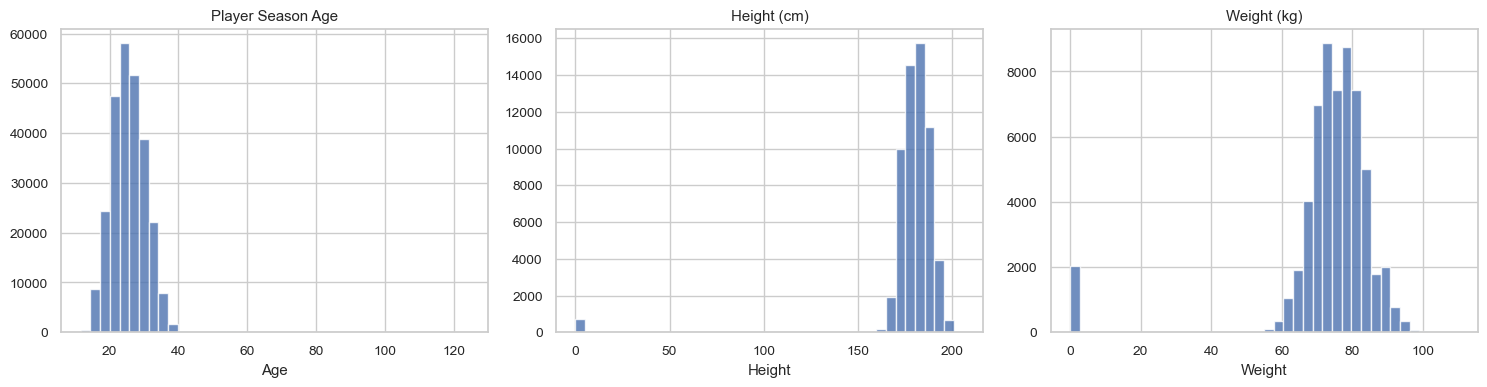

Age  — min: 12, max: 124, mean: 25.6
Height — min: 0, max: 206, nulls: 203,403
Weight — min: 0, max: 110, nulls: 203,403


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age distribution
axes[0].hist(df["player_season_age"].dropna(), bins=40, edgecolor="white", alpha=0.8)
axes[0].set_title("Player Season Age")
axes[0].set_xlabel("Age")

# Height distribution
axes[1].hist(df["wyscout_height"].dropna(), bins=40, edgecolor="white", alpha=0.8)
axes[1].set_title("Height (cm)")
axes[1].set_xlabel("Height")

# Weight distribution
axes[2].hist(df["wyscout_weight"].dropna(), bins=40, edgecolor="white", alpha=0.8)
axes[2].set_title("Weight (kg)")
axes[2].set_xlabel("Weight")

plt.tight_layout()
plt.show()

print(f"Age  — min: {df['player_season_age'].min():.0f}, max: {df['player_season_age'].max():.0f}, "
      f"mean: {df['player_season_age'].mean():.1f}")
print(f"Height — min: {df['wyscout_height'].min():.0f}, max: {df['wyscout_height'].max():.0f}, "
      f"nulls: {df['wyscout_height'].isnull().sum():,}")
print(f"Weight — min: {df['wyscout_weight'].min():.0f}, max: {df['wyscout_weight'].max():.0f}, "
      f"nulls: {df['wyscout_weight'].isnull().sum():,}")

## 4. Transfer Type Breakdown

Key question: what is the mix of transfer types? How many rows correspond to actual transfers vs. non-transfer seasons?

=== transfer_type value counts ===
                        count    pct
transfer_type                       
same_competition       184149 70.195
different_competition   78191 29.805


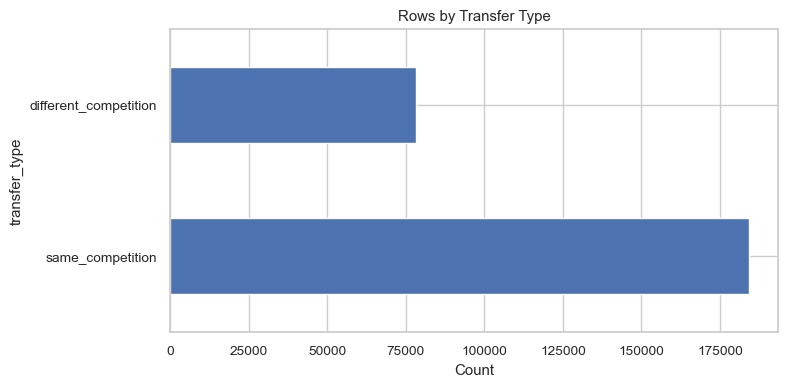

In [7]:
print("=== transfer_type value counts ===")
tt = df["transfer_type"].value_counts(dropna=False)
tt_pct = df["transfer_type"].value_counts(normalize=True, dropna=False) * 100
tt_df = pd.DataFrame({"count": tt, "pct": tt_pct})
print(tt_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
tt.plot.barh(ax=ax, edgecolor="white")
ax.set_title("Rows by Transfer Type")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

## 5. Transfer Financial Data

tm_transfer_value:
  non-null: 216,067 (82.4%)
  min=0  median=200,000  mean=1,125,675  max=180,000,000
  zeros: 37,484

tm_transfer_fee:
  non-null: 138,672 (52.9%)
  min=0  median=0  mean=1,038,368  max=222,000,000
  zeros: 110,971

tm_remaining_contract_days:
  non-null: 40,807 (15.6%)
  min=0  median=183  mean=341  max=365,544
  zeros: 11,036

Non-zero transfer fees: 27,701


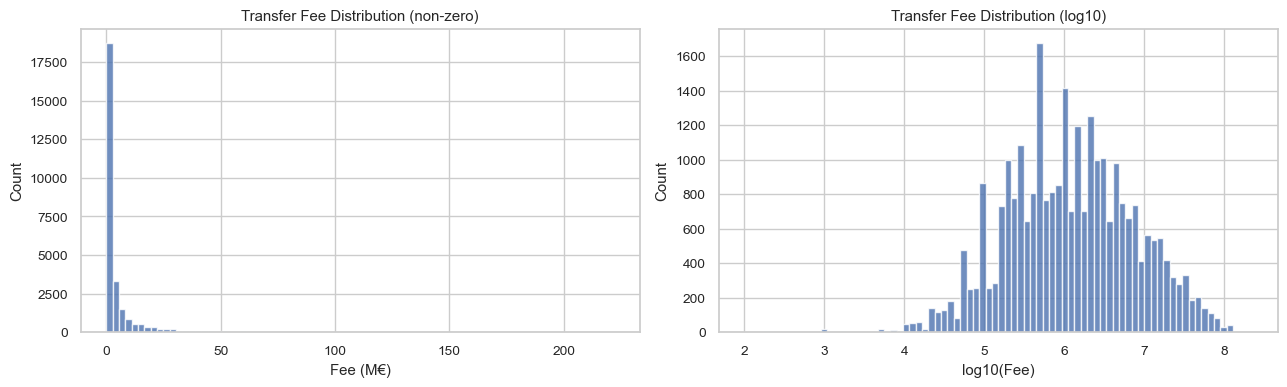

In [8]:
for col in ["tm_transfer_value", "tm_transfer_fee", "tm_remaining_contract_days"]:
    valid = df[col].dropna()
    print(f"{col}:")
    print(f"  non-null: {len(valid):,} ({100*len(valid)/len(df):.1f}%)")
    print(f"  min={valid.min():,.0f}  median={valid.median():,.0f}  mean={valid.mean():,.0f}  max={valid.max():,.0f}")
    print(f"  zeros: {(valid == 0).sum():,}")
    print()

# Distribution of transfer fee (non-zero, non-null)
fee_nonzero = df.loc[df["tm_transfer_fee"] > 0, "tm_transfer_fee"]
print(f"Non-zero transfer fees: {len(fee_nonzero):,}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(fee_nonzero / 1e6, bins=80, edgecolor="white", alpha=0.8)
axes[0].set_title("Transfer Fee Distribution (non-zero)")
axes[0].set_xlabel("Fee (M€)")
axes[0].set_ylabel("Count")

axes[1].hist(np.log10(fee_nonzero), bins=80, edgecolor="white", alpha=0.8)
axes[1].set_title("Transfer Fee Distribution (log10)")
axes[1].set_xlabel("log10(Fee)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 6. Season & Competition Coverage

In [9]:
# Season coverage
print("=== from_season distribution ===")
print(df["from_season"].value_counts().sort_index().to_string())
print()

# Competition coverage
print("=== Top 20 from_comp_name ===")
print(df["from_comp_name"].value_counts().head(20).to_string())
print()

# Countries
print("=== Top 15 from_comp_country ===")
print(df["from_comp_country"].value_counts().head(15).to_string())
print()

# Division levels
print("=== from_comp_division ===")
print(df["from_comp_division"].value_counts().sort_index().to_string())

=== from_season distribution ===
from_season
2018    29222
2019    29183
2020    34310
2021    41227
2022    42167
2023    49929
2024    35440
2025      862

=== Top 20 from_comp_name ===
from_comp_name
Premier League                9897
Primera División              7809
First League                  5086
Championship                  4343
Serie A                       4277
Serie B                       3900
Bundesliga                    3406
Pro League                    3383
Superliga                     3294
Segunda División              3236
MLS                           2992
J2 League                     2952
Ligue 1                       2871
Primera Nacional              2684
La Liga                       2629
J1 League                     2483
Super Liga                    2477
Liga Profesional de Fútbol    2438
Premiership                   2415
Super League                  2411

=== Top 15 from_comp_country ===
from_comp_country
Brazil           7231
United States    6951
E

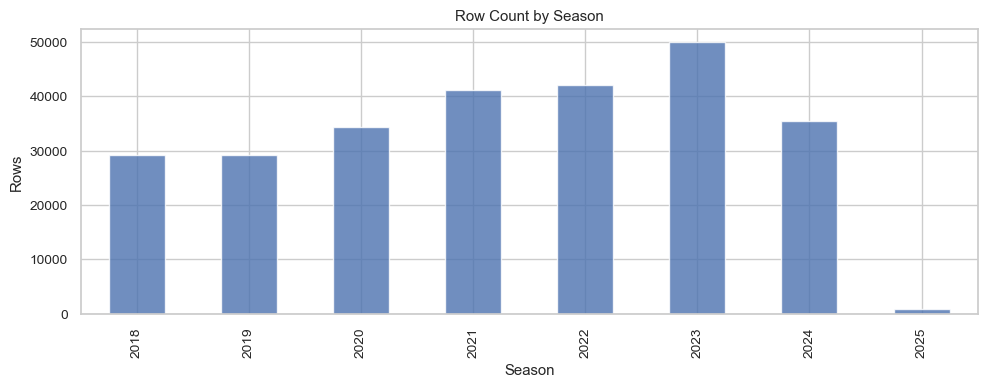

In [10]:
# Rows per season over time
fig, ax = plt.subplots(figsize=(10, 4))
df["from_season"].value_counts().sort_index().plot.bar(ax=ax, edgecolor="white", alpha=0.8)
ax.set_title("Row Count by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.show()

## 7. Playing Time Analysis

Minutes played is a critical feature — players with very few minutes have unreliable per-90 stats.

Origin minutes (from_Minutes):
  non-null: 262,340  |  zeros: 0
  min=500  p5=551  median=1255  p95=2804  max=12044
  < 90 min:  0 (0.0%)
  < 450 min: 0 (0.0%)
  < 900 min: 79,347 (30.2%)

Destination minutes (to_Minutes):
  non-null: 262,340  |  zeros: 0
  min=500  p5=547  median=1178  p95=2739  max=7734
  < 90 min:  0 (0.0%)
  < 450 min: 0 (0.0%)
  < 900 min: 86,005 (32.8%)



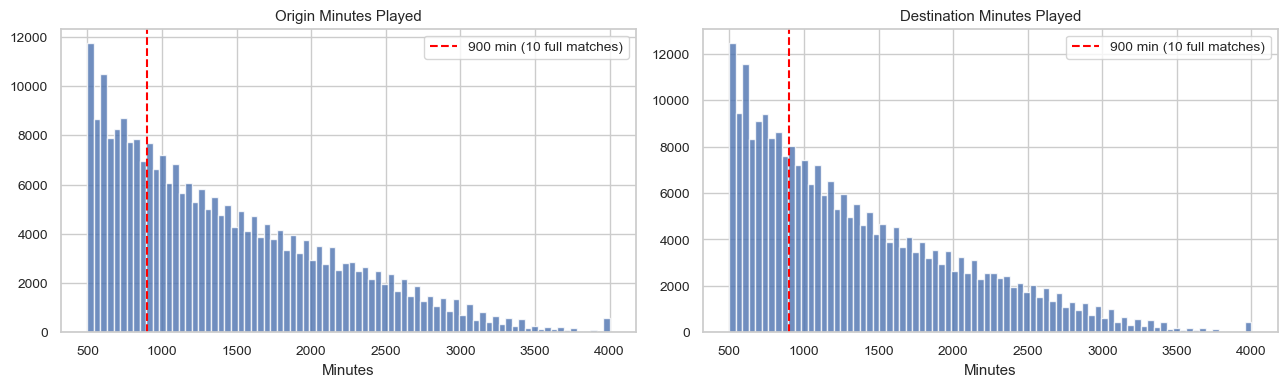

In [11]:
for prefix, label in [("from", "Origin"), ("to", "Destination")]:
    mins = df[f"{prefix}_Minutes"].dropna()
    print(f"{label} minutes ({prefix}_Minutes):")
    print(f"  non-null: {len(mins):,}  |  zeros: {(mins == 0).sum():,}")
    print(f"  min={mins.min()}  p5={mins.quantile(0.05):.0f}  median={mins.median():.0f}  "
          f"p95={mins.quantile(0.95):.0f}  max={mins.max()}")
    print(f"  < 90 min:  {(mins < 90).sum():,} ({100*(mins < 90).sum()/len(mins):.1f}%)")
    print(f"  < 450 min: {(mins < 450).sum():,} ({100*(mins < 450).sum()/len(mins):.1f}%)")
    print(f"  < 900 min: {(mins < 900).sum():,} ({100*(mins < 900).sum()/len(mins):.1f}%)")
    print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, prefix, label in zip(axes, ["from", "to"], ["Origin", "Destination"]):
    data = df[f"{prefix}_Minutes"].dropna()
    ax.hist(data.clip(upper=4000), bins=80, edgecolor="white", alpha=0.8)
    ax.axvline(900, color="red", linestyle="--", label="900 min (10 full matches)")
    ax.set_title(f"{label} Minutes Played")
    ax.set_xlabel("Minutes")
    ax.legend()
plt.tight_layout()
plt.show()

## 8. Performance Metrics — Distributions & Outliers

Quick look at a sample of key Wyscout quality scores and per-90 metrics to check for anomalies.

In [12]:
# Sample of key quality scores (Wyscout composite metrics)
quality_cols = [c for c in col_groups["from_performance"]
                if not c.startswith("from_z_score") and "per 90" not in c
                and c not in ["from_Minutes", "from_competition", "from_position",
                              "from_season", "from_team_id", "from_matches_pct", "from_minutes_pct"]]

# Show summary stats for quality scores
print(f"Number of Wyscout quality/ratio columns (from_): {len(quality_cols)}")
df[quality_cols].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]

Number of Wyscout quality/ratio columns (from_): 48


,mean,std,min,25%,50%,75%,max
from_Active defence,0.040,0.753,-3.495,-0.468,0.025,0.535,4.183
from_Aerial threat,0.027,0.734,-3.139,-0.447,0.035,0.490,4.582
from_Aerials won %,0.485,0.184,0.000,0.364,0.480,0.585,1.000
from_Attacking aerials won %,0.544,0.220,0.000,0.400,0.538,0.676,1.000
from_Box threat,0.058,0.795,-2.401,-0.523,-0.085,0.490,5.910
from_Carries (xT) per 100 receptions,0.259,0.128,0.000,0.170,0.231,0.320,4.667
from_Chance prevention,0.007,0.615,-5.105,-0.394,0.035,0.440,2.118
from_Composure,0.018,0.603,-3.031,-0.375,0.009,0.402,3.533
from_Defending 1v1 %,0.472,0.210,0.000,0.353,0.500,0.600,1.000
from_Defensive aerials won %,0.452,0.234,0.000,0.300,0.462,0.597,1.000


In [13]:
# Sample of per-90 metrics
per90_cols = [c for c in col_groups["from_performance"] if "per 90" in c]
print(f"Number of per-90 columns (from_): {len(per90_cols)}")
df[per90_cols].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]

Number of per-90 columns (from_): 46


,mean,std,min,25%,50%,75%,max
from_Aerials per 90,3.624,2.615,0.000,1.894,3.048,4.708,32.376
from_Aerials won per 90,1.732,1.380,0.000,0.721,1.368,2.368,18.546
from_Assists per 90,0.074,0.104,0.000,0.000,0.035,0.121,1.485
from_Attacking aerials won per 90,0.740,0.915,0.000,0.241,0.494,0.879,16.280
from_Ball progression (xT) per 90,0.123,0.070,0.000,0.071,0.110,0.163,0.815
from_Ball recoveries per 90,2.277,1.318,0.000,1.190,2.145,3.133,10.398
from_Ball runs (xT) per 90,0.025,0.022,0.000,0.009,0.019,0.035,0.252
from_Box entries per 90,0.328,0.442,0.000,0.000,0.161,0.470,7.462
from_Carries (xT) per 90,0.069,0.036,0.000,0.044,0.064,0.089,0.400
from_Counterpressing per 90,0.300,0.242,0.000,0.115,0.265,0.444,2.214


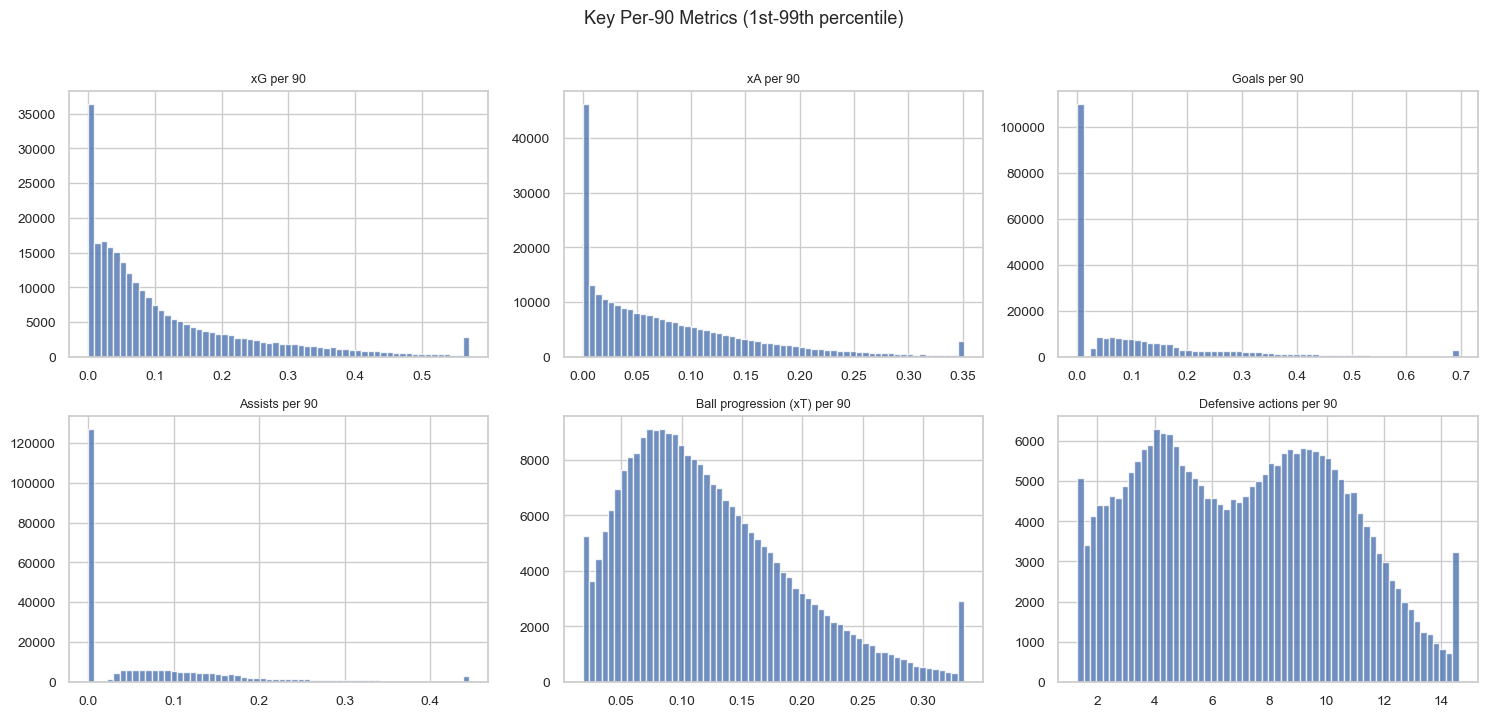

In [14]:
# Visual: distribution of a few key metrics
key_metrics = ["from_xG per 90", "from_xA per 90", "from_Goals per 90",
               "from_Assists per 90", "from_Ball progression (xT) per 90",
               "from_Defensive actions per 90"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), key_metrics):
    data = df[col].dropna()
    ax.hist(data.clip(lower=data.quantile(0.01), upper=data.quantile(0.99)),
            bins=60, edgecolor="white", alpha=0.8)
    ax.set_title(col.replace("from_", ""), fontsize=9)
    ax.set_xlabel("")
plt.suptitle("Key Per-90 Metrics (1st-99th percentile)", y=1.02)
plt.tight_layout()
plt.show()

## 9. Z-Score Sanity Check

Z-scores should be roughly centered around 0 with std ~1 if computed within position groups. Let's verify.

In [15]:
z_cols = col_groups["from_z_scores"]
z_stats = df[z_cols].describe().T[["mean", "std", "min", "max"]]
z_stats.columns = ["mean", "std", "min", "max"]

print(f"Z-score columns: {len(z_cols)}")
print(f"Mean of means:  {z_stats['mean'].mean():.4f}")
print(f"Mean of stds:   {z_stats['std'].mean():.4f}")
print(f"Columns with |mean| > 0.1: {(z_stats['mean'].abs() > 0.1).sum()}")
print(f"Columns with std < 0.5 or std > 2.0: {((z_stats['std'] < 0.5) | (z_stats['std'] > 2.0)).sum()}")
print()

# Any extreme z-scores?
z_abs_max = df[z_cols].abs().max()
print(f"Max absolute z-score across all columns: {z_abs_max.max():.1f} ({z_abs_max.idxmax()})")
print(f"Columns with |z| > 10: {(z_abs_max > 10).sum()}")
print(f"Columns with |z| > 5:  {(z_abs_max > 5).sum()}")

Z-score columns: 75
Mean of means:  0.0399
Mean of stds:   0.9913
Columns with |mean| > 0.1: 1
Columns with std < 0.5 or std > 2.0: 0

Max absolute z-score across all columns: 17.6 (from_z_score_Goals per box touch)
Columns with |z| > 10: 19
Columns with |z| > 5:  71


## 10. Team Stats Overview

In [16]:
ts_cols = col_groups["from_team_stats"]
print(f"Team stats columns (from_): {len(ts_cols)}")
print()

# Missing pattern in team stats
ts_missing = df[ts_cols].isnull().sum() / len(df) * 100
print(f"Team stats missing % — min: {ts_missing.min():.1f}%, max: {ts_missing.max():.1f}%, "
      f"mean: {ts_missing.mean():.1f}%")
print()

# Unique teams
print(f"Unique from_team_id: {df['from_team_id'].nunique():,}")
print(f"Unique to_team_id:   {df['to_team_id'].nunique():,}")
print()

# Sample stats
sample_ts = ["from_team_stats_ball_possession_pct", "from_team_stats_ppda",
             "from_team_stats_xg", "from_team_stats_goals", "from_team_stats_points"]
df[sample_ts].describe().T[["mean", "std", "min", "50%", "max"]]

Team stats columns (from_): 74

Team stats missing % — min: 9.4%, max: 9.4%, mean: 9.4%

Unique from_team_id: 5,853
Unique to_team_id:   5,777



,mean,std,min,50%,max
from_team_stats_ball_possession_pct,0.503,0.058,0.240,0.500,0.770
from_team_stats_ppda,5.322,1.102,1.480,5.190,22.230
from_team_stats_xg,1.386,0.377,0.060,1.340,5.560
from_team_stats_goals,1.354,0.510,0.000,1.292,9.000
from_team_stats_points,1.403,0.524,0.000,1.353,3.000


## 11. From vs. To Completeness

How many rows have both "from" and "to" data populated? This tells us how many are usable for pre/post transfer comparison.

In [17]:
has_from = df["from_Minutes"].notna()
has_to = df["to_Minutes"].notna()

print(f"Has from data:     {has_from.sum():,} ({100*has_from.mean():.1f}%)")
print(f"Has to data:       {has_to.sum():,} ({100*has_to.mean():.1f}%)")
print(f"Has both:          {(has_from & has_to).sum():,} ({100*(has_from & has_to).mean():.1f}%)")
print(f"Has neither:       {(~has_from & ~has_to).sum():,} ({100*(~has_from & ~has_to).mean():.1f}%)")
print(f"From only:         {(has_from & ~has_to).sum():,}")
print(f"To only:           {(~has_from & has_to).sum():,}")
print()

# Among rows with both, how does transfer_type break down?
both_mask = has_from & has_to
print("Transfer type distribution (rows with both from & to data):")
print(df.loc[both_mask, "transfer_type"].value_counts(dropna=False).to_string())

Has from data:     262,340 (100.0%)
Has to data:       262,340 (100.0%)
Has both:          262,340 (100.0%)
Has neither:       0 (0.0%)
From only:         0
To only:           0

Transfer type distribution (rows with both from & to data):
transfer_type
same_competition         184149
different_competition     78191


## 12. Correlation Structure (Sample)

Quick look at correlations among key metrics to understand redundancy.

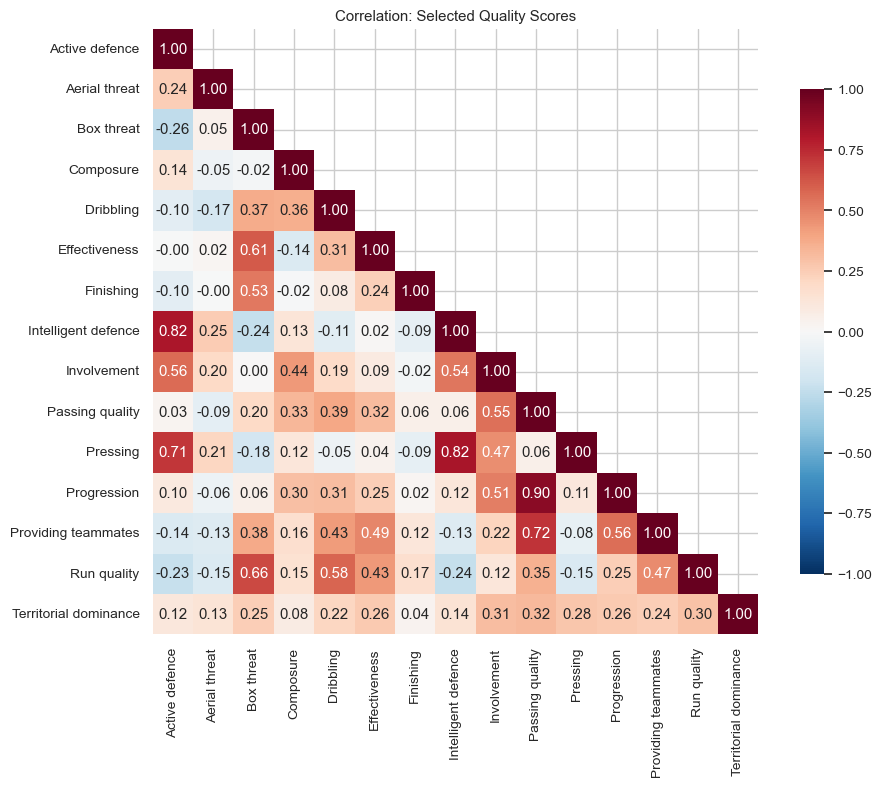

In [18]:
# Correlation heatmap of selected quality scores
sample_quality = [
    "from_Active defence", "from_Aerial threat", "from_Box threat",
    "from_Composure", "from_Dribbling", "from_Effectiveness",
    "from_Finishing", "from_Intelligent defence", "from_Involvement",
    "from_Passing quality", "from_Pressing", "from_Progression",
    "from_Providing teammates", "from_Run quality", "from_Territorial dominance",
]

corr = df[sample_quality].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, xticklabels=[c.replace("from_", "") for c in sample_quality],
            yticklabels=[c.replace("from_", "") for c in sample_quality],
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation: Selected Quality Scores")
plt.tight_layout()
plt.show()

## 13. Duplicate & Consistency Checks

In [19]:
# Exact duplicate rows
n_dup = df.duplicated().sum()
print(f"Exact duplicate rows: {n_dup:,}")

# Potential natural key: player + from_season + from_team_id + from_competition
key_cols = ["wy_player_id", "from_season", "from_team_id", "from_competition"]
n_dup_key = df.duplicated(subset=key_cols).sum()
print(f"Duplicate on (player, season, team, competition): {n_dup_key:,}")

# Player + from_season + from_team_id
key_cols2 = ["wy_player_id", "from_season", "from_team_id"]
n_dup_key2 = df.duplicated(subset=key_cols2).sum()
print(f"Duplicate on (player, season, team): {n_dup_key2:,}")
print()

# Check: does from_position change within a player across rows?
pos_per_player = df.groupby("wy_player_id")["from_position"].nunique()
print(f"Players with multiple from_positions across rows: "
      f"{(pos_per_player > 1).sum():,} / {len(pos_per_player):,}")

# Check: does wyscout_role match from_position?
if "wyscout_role" in df.columns and "from_position" in df.columns:
    mismatch = (df["wyscout_role"] != df["from_position"]).sum()
    print(f"Rows where wyscout_role != from_position: {mismatch:,}")

Exact duplicate rows: 0
Duplicate on (player, season, team, competition): 46,833
Duplicate on (player, season, team): 48,030

Players with multiple from_positions across rows: 19,164 / 83,477
Rows where wyscout_role != from_position: 243,314


## 14. Potential Issues & Flags

Summary of data quality concerns to investigate before modeling.

In [20]:
issues = []

# 1. Low minutes
low_min_from = (df["from_Minutes"] < 450).sum()
low_min_to = (df["to_Minutes"].dropna() < 450).sum()
issues.append(f"1. LOW PLAYING TIME: {low_min_from:,} rows with from_Minutes < 450 — "
              f"per-90 metrics may be unreliable for these players.")

# 2. Missing to_ data
to_null = df["to_Minutes"].isnull().sum()
issues.append(f"2. MISSING POST-TRANSFER DATA: {to_null:,} rows ({100*to_null/len(df):.1f}%) "
              f"have no destination data — these are likely non-transfer seasons or data gaps.")

# 3. Transfer fee info
fee_null = df["tm_transfer_fee"].isnull().sum()
issues.append(f"3. MISSING TRANSFER FEES: {fee_null:,} rows ({100*fee_null/len(df):.1f}%) "
              f"have no transfer fee — expected for non-transfer rows, but verify for actual transfers.")

# 4. Extreme z-scores
extreme_z = (df[col_groups["from_z_scores"]].abs() > 5).sum().sum()
issues.append(f"4. EXTREME Z-SCORES: {extreme_z:,} individual cell values with |z| > 5 — "
              f"may indicate outliers or low-sample players.")

# 5. Team stats missingness
ts_miss = df[col_groups["from_team_stats"]].isnull().any(axis=1).sum()
issues.append(f"5. TEAM STATS GAPS: {ts_miss:,} rows missing at least one from_team_stats column.")

# 6. Image URL (noise column)
issues.append(f"6. NOISE COLUMN: 'wyscout_image_url' is not useful for modeling — drop before training.")

# 7. Duplicate keys
issues.append(f"7. DUPLICATE KEYS: {n_dup_key:,} rows share the same (player, season, team, competition) — "
              f"understand if these represent legitimate multi-row entries or data errors.")

for issue in issues:
    print(issue)
    print()

1. LOW PLAYING TIME: 0 rows with from_Minutes < 450 — per-90 metrics may be unreliable for these players.

2. MISSING POST-TRANSFER DATA: 0 rows (0.0%) have no destination data — these are likely non-transfer seasons or data gaps.

3. MISSING TRANSFER FEES: 123,668 rows (47.1%) have no transfer fee — expected for non-transfer rows, but verify for actual transfers.

4. EXTREME Z-SCORES: 14,599 individual cell values with |z| > 5 — may indicate outliers or low-sample players.

5. TEAM STATS GAPS: 24,709 rows missing at least one from_team_stats column.

6. NOISE COLUMN: 'wyscout_image_url' is not useful for modeling — drop before training.

7. DUPLICATE KEYS: 46,833 rows share the same (player, season, team, competition) — understand if these represent legitimate multi-row entries or data errors.



## 15. Quick Sample — Spot Check

A few random rows to visually inspect the data makes sense end-to-end.

In [21]:
# Show a few rows with key columns for a well-known player (if available)
spot_cols = [
    "wy_player_id", "short_name", "wyscout_role", "player_season_age",
    "transfer_type", "from_season", "from_position", "from_Minutes",
    "from_comp_name", "from_comp_country",
    "to_season", "to_position", "to_Minutes", "to_comp_name",
    "tm_transfer_fee", "tm_transfer_value",
]

# Random sample of 10 rows that have both from and to data
sample = df.loc[df["to_Minutes"].notna()].sample(10, random_state=42)
sample[spot_cols]

,wy_player_id,short_name,wyscout_role,player_season_age,transfer_type,from_season,from_position,from_Minutes,from_comp_name,from_comp_country,to_season,to_position,to_Minutes,to_comp_name,tm_transfer_fee,tm_transfer_value
34241,566996,K. Mabea,None,24.841,different_competition,2023,Full Back,1166,Ligat ha'Al,Israel,2023,Full Back,1334,Liga Leumit,0.000,250000.000
18386,234803,R. Jensen,None,28.339,different_competition,2024,Central Defender,589,Superliga,Denmark,2025,Central Defender,508,Super League 2,0.000,550000.000
49919,197665,E. Popov,None,30.423,different_competition,2018,Striker,1154,None,None,2019,Winger,1235,First League,<NA>,<NA>
161336,402924,A. Di Munno,None,22.992,same_competition,2023,Midfielder,2674,None,None,2024,Midfielder,1824,None,<NA>,225000.000
257276,535774,K. Sibo,None,23.176,same_competition,2021,Midfielder,1361,None,None,2022,Midfielder,2803,None,0.000,200000.000
232612,229267,Y. Niakaté,None,30.667,same_competition,2023,Striker,2112,UAE Pro League,United Arab Emirates,2024,Striker,1999,UAE Pro League,0.000,800000.000
884,209403,C. Arce,None,30.486,different_competition,2021,Midfielder,2458,Primera Nacional,Argentina,2022,Midfielder,2304,Liga Profesional de Fútbol,<NA>,50000.000
158975,407059,L. Di Cosmo,None,21.906,same_competition,2020,Midfielder,1519,None,None,2021,Full Back,672,None,<NA>,150000.000
203558,356601,A. Borisov,None,23.176,same_competition,2020,Full Back,1021,None,None,2021,Full Back,1163,None,<NA>,0.000
230126,762591,D. Garkavenko,None,20.411,same_competition,2024,Central Defender,857,None,None,2025,Central Defender,1342,None,0.000,0.000


## Summary

**Strengths:**
- Rich feature set: 539 columns covering player identity, transfer metadata, pre/post performance (raw + z-scored), and team context
- Good temporal coverage (2018-2025 seasons)
- Z-scores enable cross-position comparison
- Team stats provide contextual information about playing environment

**Key concerns to address before modeling:**
1. **Playing time filter** — many rows may have very low minutes, making per-90 stats noisy
2. **Missing "to" data** — a significant portion of rows lack post-transfer metrics
3. **Duplicate keys** — need to understand the grain of the dataset precisely
4. **Column redundancy** — raw metrics, z-scores, and quality scores may overlap; dimensionality reduction or feature selection warranted
5. **Transfer fee missingness** — expected for non-transfers, but verify completeness for actual transfer rows
6. **Drop noise columns** — `wyscout_image_url` and potentially others before training